### Beijing Multi-Site Air Quality

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
air_quality_data = np.load('../dataset/AirQuality/air_quality_data.npy')
air_quality_norm = np.load('../dataset/AirQuality/air_quality_data_norm.npy')
air_quality_adj = np.load('../dataset/AirQuality/air_quality_adj.npy')
air_stations = pd.read_csv('../dataset/raw/beijing_air_stations.csv')
air_quality_data_2d = air_quality_data.reshape(air_quality_data.shape[0], -1)

## Temporal EDA

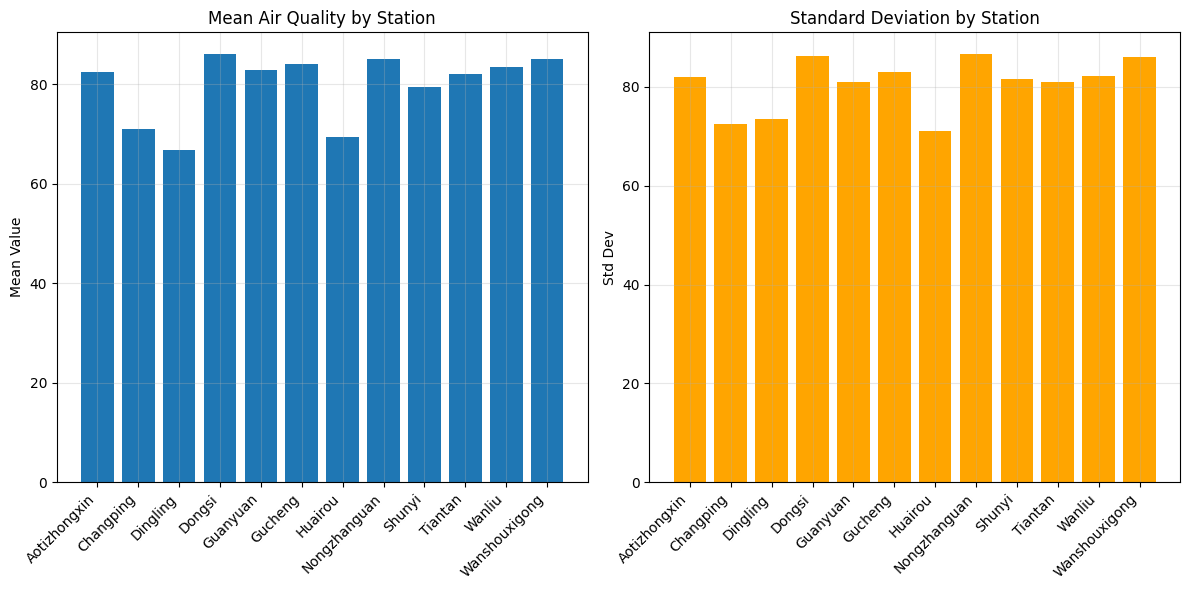

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Mean values by station
station_means = air_quality_data_2d.mean(axis=0)
axes[0].bar(range(len(station_means)), station_means)
axes[0].set_xticks(range(len(air_stations)))
axes[0].set_xticklabels(air_stations['Station'], rotation=45, ha='right')
axes[0].set_ylabel('Mean Value')
axes[0].set_title('Mean Air Quality by Station')
axes[0].grid(True, alpha=0.3)

# Standard deviation by station
station_std = air_quality_data_2d.std(axis=0)
axes[1].bar(range(len(station_std)), station_std, color='orange')
axes[1].set_xticks(range(len(air_stations)))
axes[1].set_xticklabels(air_stations['Station'], rotation=45, ha='right')
axes[1].set_ylabel('Std Dev')
axes[1].set_title('Standard Deviation by Station')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../Results/Plots/air_quality_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
air_quality_data_2d.shape

(35064, 12)

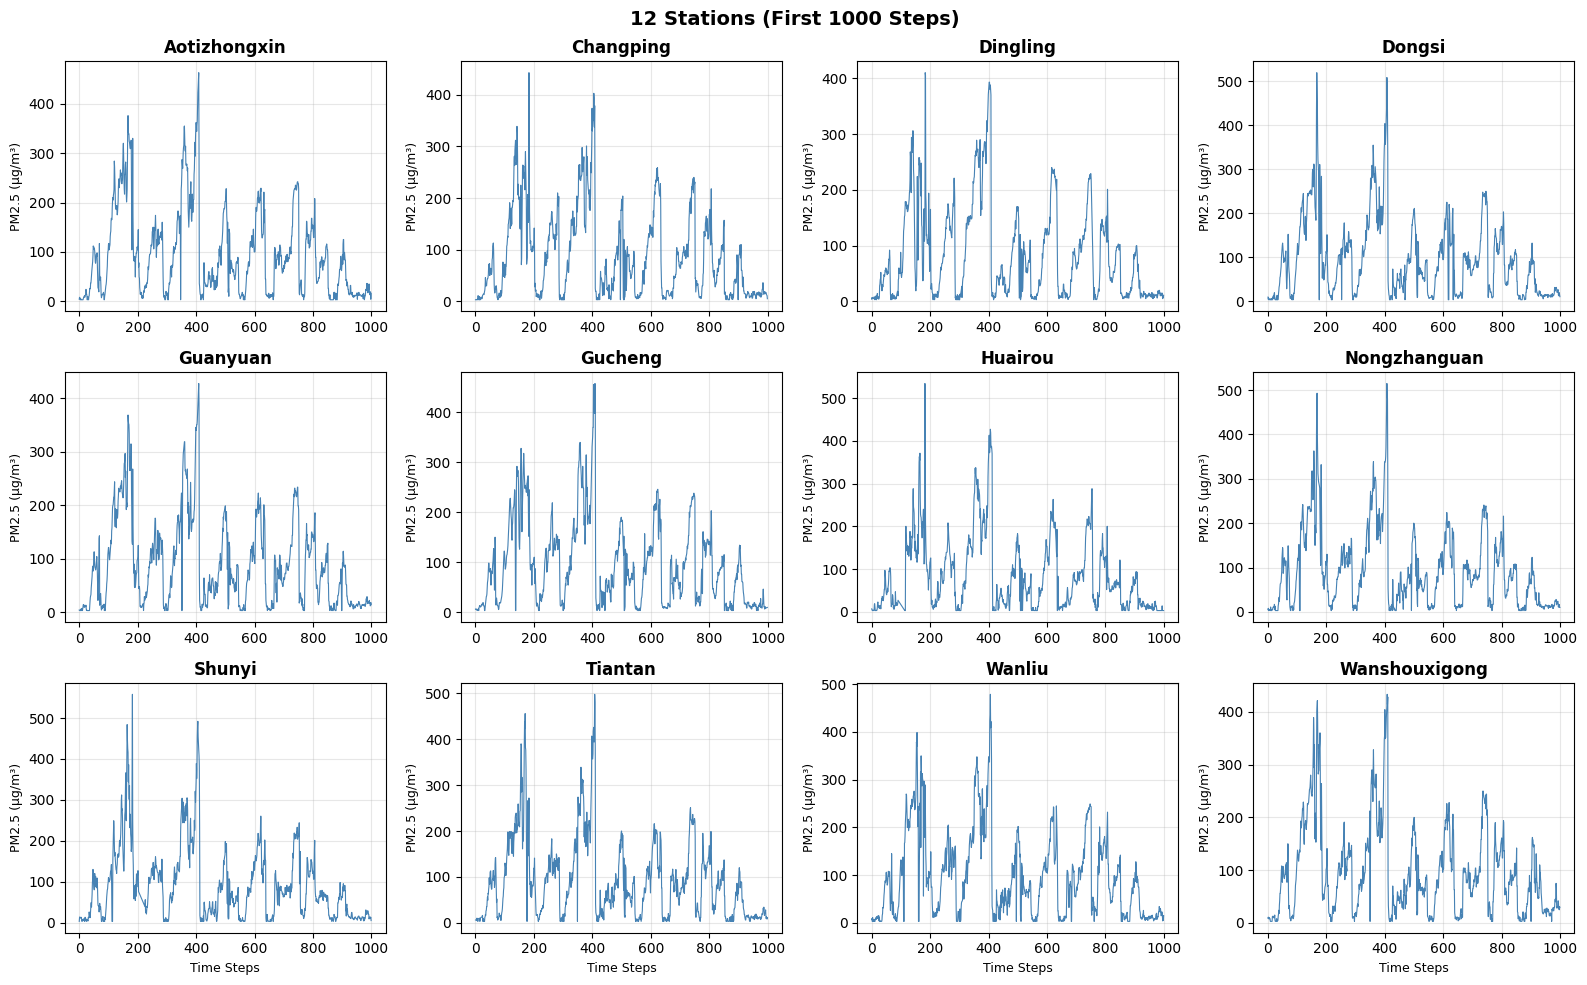

In [62]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i in range(len(air_stations)):
    axes[i].plot(air_quality_data_2d[:1000, i], linewidth=0.8, color='steelblue')
    axes[i].set_title(f'{air_stations.iloc[i]["Station"]}', fontweight='bold')
    axes[i].set_ylabel('PM2.5 (μg/m³)', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    if i >= 8:
        axes[i].set_xlabel('Time Steps', fontsize=9)

plt.suptitle("12 Stations (First 1000 Steps)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Results/Plots/air_quality_timeseries_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## Air quality station map

In [ ]:
import folium
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Create a map centered on Beijing
beijing_center = [39.9042, 116.4074]
m = folium.Map(
    location=beijing_center,
    zoom_start=11,
    tiles='OpenStreetMap'
)

# Normalize station means for color mapping
norm = Normalize(vmin=station_means.min(), vmax=station_means.max())
cmap = cm.get_cmap('RdYlGn')

# Add markers for each station
for idx, row in air_stations.iterrows():
    color_value = 1 - norm(station_means[idx])
    rgba = cmap(color_value)
    hex_color = '#{:02x}{:02x}{:02x}'.format(
        int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255)
    )
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        popup=f"<b>{row['Station']}</b><br>Mean PM2.5: {station_means[idx]:.2f}",
        tooltip=f"{row['Station']}: {station_means[idx]:.2f}",
        color=hex_color,
        fill=True,
        fillColor=hex_color,
        fillOpacity=0.8,
        weight=2
    ).add_to(m)

# Get actual colors for legend
median_val = np.median(station_means)
high_color = cmap(1 - norm(station_means.max()))
high_hex = '#{:02x}{:02x}{:02x}'.format(
    int(high_color[0]*255), int(high_color[1]*255), int(high_color[2]*255)
)

mid_color = cmap(1 - norm(median_val))
mid_hex = '#{:02x}{:02x}{:02x}'.format(
    int(mid_color[0]*255), int(mid_color[1]*255), int(mid_color[2]*255)
)

low_color = cmap(1 - norm(station_means.min()))
low_hex = '#{:02x}{:02x}{:02x}'.format(
    int(low_color[0]*255), int(low_color[1]*255), int(low_color[2]*255)
)

legend_html = '''
<div style="position: fixed; 
     bottom: 50px; right: 50px; width: 160px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 8px; border-radius: 5px;">
     
<p style="margin: 0 0 8px 0; font-weight: bold; font-size: 13px;">PM2.5 Levels</p>

<i style="background: {high_hex}; width: 16px; height: 16px; float: left; margin-right: 6px; border-radius: 50%;"></i>
<span style="font-size: 11px;">High ({max_val:.1f})</span><br style="clear: both;">

<i style="background: {mid_hex}; width: 16px; height: 16px; float: left; margin-right: 6px; border-radius: 50%;"></i>
<span style="font-size: 11px;">Moderate ({med_val:.1f})</span><br style="clear: both;">

<i style="background: {low_hex}; width: 16px; height: 16px; float: left; margin-right: 6px; border-radius: 50%;"></i>
<span style="font-size: 11px;">Low ({min_val:.1f})</span><br style="clear: both;">

<hr style="margin: 6px 0; border: none; border-top: 1px solid #ddd;">

<p style="margin: 5px 0; font-size: 10px; line-height: 1.4;">
Mean: {mean_val:.1f}<br>
Max: {max_val:.1f}
</p>
</div>
'''.format(
    high_hex=high_hex,
    mid_hex=mid_hex,
    low_hex=low_hex,
    max_val=station_means.max(),
    med_val=median_val,
    min_val=station_means.min(),
    mean_val=station_means.mean()
)

m.get_root().html.add_child(folium.Element(legend_html))
m.save('../Results/Plots/air_quality_map.html')

In [64]:
stats_df = pd.DataFrame({
    'Station': air_stations['Station'],
    'Mean': air_quality_data_2d.mean(axis=0),
    'Std': air_quality_data_2d.std(axis=0),
    'Min': air_quality_data_2d.min(axis=0),
    'Max': air_quality_data_2d.max(axis=0),
    'Median': np.median(air_quality_data_2d, axis=0)
})
print(stats_df.to_string(index=False))

stats_df.to_csv('../Results/Performance/air_quality_statistics.csv', index=False)

      Station      Mean       Std  Min   Max  Median
 Aotizhongxin 82.540627 81.955231  3.0 898.0    58.0
    Changping 70.986443 72.396690  2.0 882.0    46.0
     Dingling 66.845551 73.444046  3.0 881.0    41.0
       Dongsi 86.144241 86.259018  3.0 737.0    61.0
     Guanyuan 82.897514 81.069122  2.0 680.0    59.0
      Gucheng 84.074799 82.993454  2.0 770.0    60.0
      Huairou 69.501747 70.989891  2.0 762.0    47.0
 Nongzhanguan 85.079468 86.691277  2.0 844.0    59.0
       Shunyi 79.437965 81.499123  2.0 941.0    55.0
      Tiantan 82.033096 80.894341  3.0 821.0    58.0
       Wanliu 83.467613 82.123886  2.0 957.0    59.0
Wanshouxigong 85.067551 85.998466  3.0 999.0    60.0
